In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pre_processing import pre_process, json_decode


sns.set_palette("hsv_r")

# This affects things like the size of the labels, lines, and other elements of the plot, but not the overall style. 
# The base context is “notebook”, and the other contexts are “paper”, “talk”, and “poster”, which are version of 
# the notebook parameters scaled by .8, 1.3, and 1.6, respectively.
sns.set_context("talk")

%config Inline.figure_format = 'retina'
%matplotlib inline

# new 

## Read in Data 

In [2]:
# File paths for each experimental condition (can contain multiple subjects/files) 
file_paths_baseline = [
    # "../data/csv_files/01_baseline_withoutFB.csv",   # Abby1 60
    "../data/csv_files/02_baseline_withoutFB.csv",     # Yannie 
    "../data/csv_files/03_baseline_withoutFB.csv",   # Eric1 60 
    "../data/csv_files/04_baseline_withoutFB.csv",     # Paul
    "../data/csv_files/05_baseline_withoutFB.csv",     # Jason 60
    # "../data/csv_files/01_baseline_withFB.csv",        # Eric2  60
    "../data/csv_files/02_baseline_withFB.csv",      # Abby2
    "../data/csv_files/03_baseline_withFB.csv",        # Rainie 60
    "../data/csv_files/04_baseline_withFB.csv",        # Alice 
    "../data/csv_files/05_baseline_withFB.csv"         # Rhys 60
]

file_paths_repulse = [
    # "../data/csv_files/01_repulse_withoutFB.csv",    # Abby1
    "../data/csv_files/02_repulse_withoutFB.csv",      # Yannie 
    "../data/csv_files/03_repulse_withoutFB.csv",    # Eric1
    "../data/csv_files/04_repulse_withoutFB.csv",      # Paul
    "../data/csv_files/05_repulse_withoutFB.csv",      # Jason
    # "../data/csv_files/01_repulse_withFB.csv",         # Eric2 
    "../data/csv_files/02_repulse_withFB.csv",       # Abby2
    "../data/csv_files/03_repulse_withFB.csv",         # Rainie 
    "../data/csv_files/04_repulse_withFB.csv",         # Alice 
    "../data/csv_files/05_repulse_withFB.csv"          # Rhys
]

file_paths_udl = [
    # "../data/csv_files/01_udl_withoutFB.csv",        # Abby1
    "../data/csv_files/02_udl_withoutFB.csv",          # Yannie
    "../data/csv_files/03_udl_withoutFB.csv",        # Eric1
    "../data/csv_files/04_udl_withoutFB.csv",          # Paul
    "../data/csv_files/05_udl_withoutFB.csv",          # Jason
    # "../data/csv_files/01_udl_withFB.csv",             # Eric2 
    "../data/csv_files/02_udl_withFB.csv",           # Abby2
    "../data/csv_files/03_udl_withFB.csv",             # Rainie 
    "../data/csv_files/04_udl_withFB.csv",             # Alice 
    "../data/csv_files/05_udl_withFB.csv"              # Rhys
]

# Subject identifiers corresponding to the datasets
# subject_list = ["yannie", "paul", "jason", "eric", "rainie", "alice", "rhys"]
# subject_list = ["abby1", "yannie", "eric1", "paul", "jason", "eric2", "abby2", "rainie", "alice", "rhys"]
subject_list = ["yannie", "eric1", "paul", "jason", "abby2", "rainie", "alice", "rhys"]

# Load CSV files & label condition
df_baseline_raw = pre_process(file_paths_baseline, subject_list)
df_baseline_raw['phase'] = 'baseline'

df_repulse_raw = pre_process(file_paths_repulse, subject_list)
df_repulse_raw['phase'] = 'repulse'

df_udl_raw = pre_process(file_paths_udl, subject_list)
df_udl_raw['phase'] = 'udl'

# Combine all conditions into a single dataset
df = pd.concat([df_baseline_raw, df_repulse_raw, df_udl_raw]).reset_index(drop=True)

# Reset the trial number column that resets for each subject
df["TN"] = df.groupby("SN").cumcount()

# CHECK 
# print(df['phase'].value_counts())
# print(df.head())


## Define Functions 

In [3]:
# function to unpack repeated target value from series
# WE HAVENT USE THIS ONE YET.. copied from Jeremy's analysis script
def find_rep(group):
    vals = group['Repeated_Target'].iloc[0]
    return vals[1:4]   

#function returns df where N-1 is a single target, 
#to compare the repulsive and attractive effect of a single target
def N_finder(group, N_minus_targ):
    N_trial_num = group.loc[(group['target_angle'] == N_minus_targ),'TN'] + 1
    N_df = group.loc[(group['TN'].isin(N_trial_num))]
    return N_df

def add_bias_correction(df, angle_col, phase_name, epoch):
    """
    calcylate target-specific bias and corrected angle for a given phase and angle column
    """
    bias_col = f"bias_{phase_name}_{angle_col}"
    corrected_col = f"corrected_{phase_name}_{angle_col}"

    bias = (
        df.loc[
            (df["TN"] >= epoch[0]) &
            (df["TN"] <= epoch[1]) &
            (~df["mt"].isna()) &
            (df["rt"] > 0.5) &
            (df[angle_col].abs() < 60)
        ]
        .groupby(["SN", "target_angle"], as_index=False)[angle_col]
        .mean()
        .rename(columns={angle_col: bias_col})
    )

    # merge bias back into dataframe
    df = df.merge(bias, on=["SN", "target_angle"], how="left")

    # wrap the angle
    diff = np.deg2rad(df[angle_col] - df[bias_col])

    df[corrected_col] = np.rad2deg(
        np.arctan2(np.sin(diff), np.cos(diff))
    )
    return df

def calculate_se_index(df, y_col):
    """
    calculate the sequential effect (SE) index per participant 
    POSITIVE SE Index = attractive bias (UDL)
    NEGATIVE SE Index = repulsive bias (REPULSE)

    parameters: 
    df : DataFrame; data to calculate SE index from
    y_col : str; column containing corrected bias

    output: 
    df with the SE index per participant 
    """
    negative_mean = df.loc[df["target_angle_diff"] < 0].groupby("SN")[y_col].mean().copy()
    positive_mean = df.loc[df["target_angle_diff"] > 0].groupby("SN")[y_col].mean().copy()

    return negative_mean - positive_mean 

## should probably create a function that determines the repeated target and changes all the targets to be centred around ZERO 

## Data Wrangling 

In [4]:
## Define epochs for each phase of the experiment (trial number ranges for each phase)
epochs = {
    'baseline':(0, 15),      # Baseline reaching
    'repulse':(16, 715),   # Main experiment block
    'repulse_clean':(116, 715),   # For bias correction
}

## running add_bias_correction for all angle calculations & 
angle_cols = ["theta_40", "theta_100", "theta_pv", "theta_end"]
phase_info = {
    "repulse": epochs["repulse_clean"]}

for phase_name, epoch in phase_info.items():
    for angle in angle_cols:
        df = add_bias_correction(
            df,
            angle_col=angle,
            phase_name=phase_name,
            epoch=epoch
        )

## Shift the target angles for participants who had a central target of 60 degrees, so that central target is always at 150 degrees 
# Participants who had central target as 60 degrees
p_list1 = [2, 4, 6, 8]
# p_list1 = [1, 3, 5, 6, 8, 10]

# Shift all targets so central target is always 150 degrees
mask = df['SN'].isin(set(p_list1))
TA_rad_shift = np.deg2rad(df.loc[mask]['target_angle']) + np.deg2rad(90)
df.loc[mask,'target_angle'] = (np.rad2deg(np.arctan2(np.sin(TA_rad_shift), np.cos(TA_rad_shift))) % 360).round()

# Get target location difference values
df['target_angle_diff'] = pd.Series(pd.NA, index=df.index, dtype='Float64')
# NOTES:
# 1) CW is negative, CCW is positive 
# 2) add one to starting index because we want the first trial for every block to be NA
mask = (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1])
RadTAN1diff_repulse = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1)) 
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_repulse), np.cos(RadTAN1diff_repulse)))

# Round 
df['target_angle_diff'] = df['target_angle_diff'].round().astype('Int64')

# Plot bias across all random phase trials

Text(0, 0.5, 'Corrected Bias')

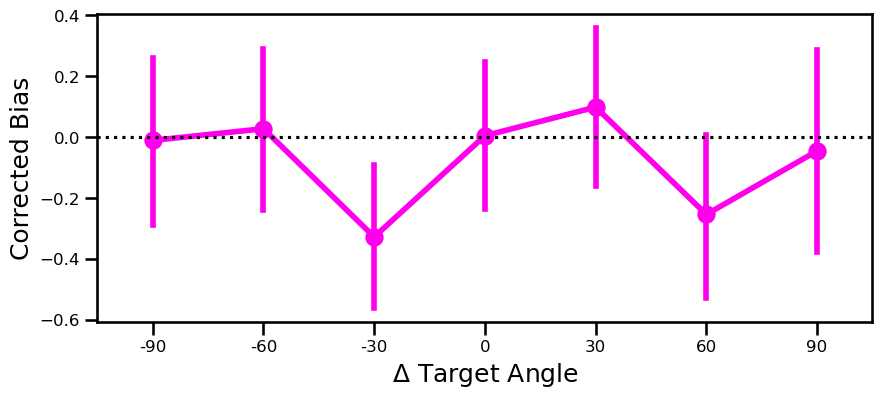

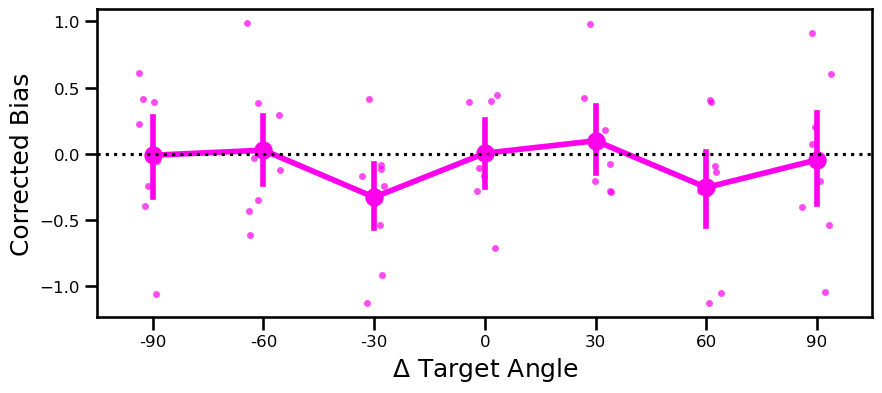

In [5]:
repulse_mask = (
    (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
    (~df['mt'].isna()) & # take the median of the RT and MT and mean of the medians 
    (df['rt'] > 0.5) &  
    (df["target_angle_diff"].abs() <= 90) &
    (np.abs(df['theta_pv']) < 60)
)

df_repulse = df.loc[repulse_mask].copy()

subject_means_repulse = (
    df_repulse
    .groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv']
    .mean()
    .reset_index()
)


fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    # to look at a single subject (comment)
    # data = df_repulse.loc[df_repulse["SN"] == 2],
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

fig2, ax2 = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax2
)
sns.stripplot(
    data=subject_means_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    #color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax2
)
ax2.axhline(0, color='black', linestyle=':')
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

# plt.savefig('repulse_all.png', dpi=600, bbox_inches='tight')


Text(0, 0.5, 'Corrected Bias')

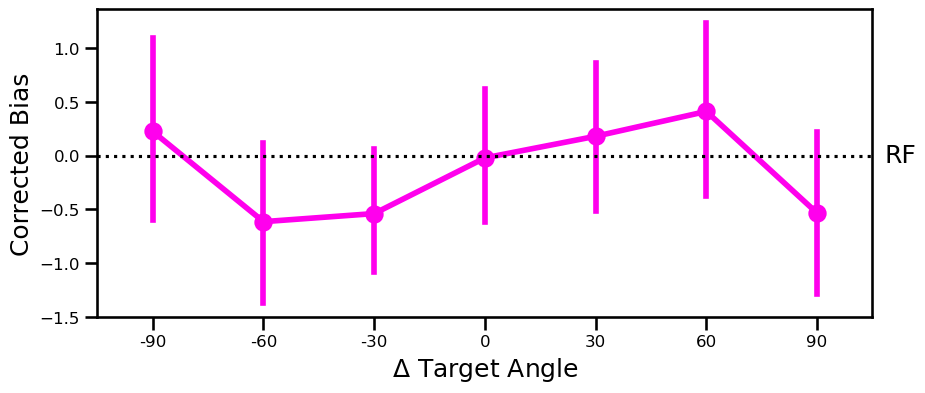

In [6]:
## By participant 

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    # data=df_repulse,
    # # to look at a single subject (comment)
    data = df_repulse.loc[df_repulse["SN"] == 6],
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.set_title("RF", x=1.015, y=0.5,va="center", ha="left")

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# lowkey looks wack this way 

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

# plt.savefig('RF_repulse.png', dpi=600, bbox_inches='tight')


Text(0, 0.5, 'Corrected Bias')

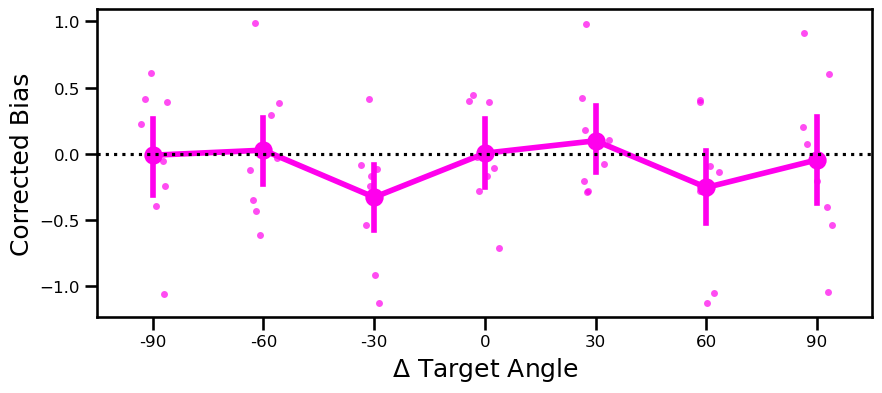

In [7]:
df_repulse_constrained90 = df_repulse[df_repulse["target_angle_diff"].abs() <= 90].copy()

subject_means_repulse = (
    df_repulse_constrained90
    .groupby(['SN', 'target_angle_diff'])['corrected_repulse_theta_pv' ]
    .mean()
    .reset_index()
)


fig2, ax2 = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse_constrained90,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax2
)
sns.stripplot(
    data=subject_means_repulse,
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    #color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax2
)
ax2.axhline(0, color='black', linestyle=':')
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

# plt.savefig('constrict.png', dpi=600, bbox_inches='tight')

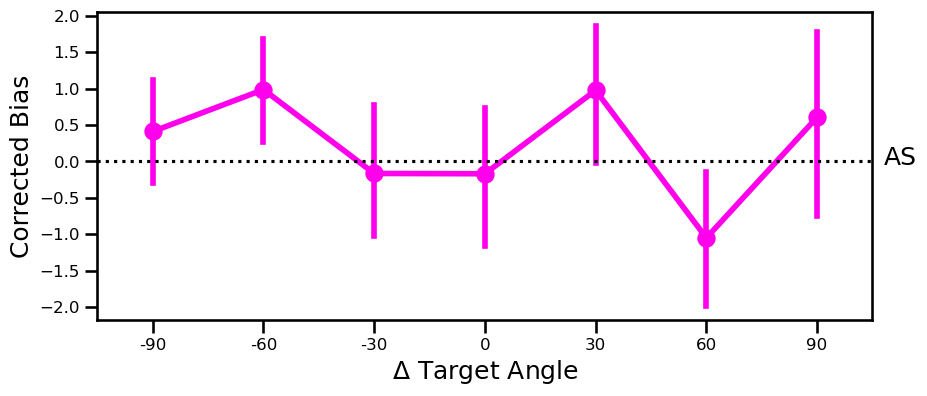

In [8]:
## By participant 

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    # data=df_repulse_constrained90,
    # # to look at a single subject (comment)
    data = df_repulse_constrained90.loc[df_repulse_constrained90["SN"] == 5],
    x='target_angle_diff',
    y='corrected_repulse_theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.set_title("AS", x=1.015, y=0.5,va="center", ha="left")

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# lowkey looks wack this way 

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

plt.savefig('AS_repulse.png', dpi=600, bbox_inches='tight')

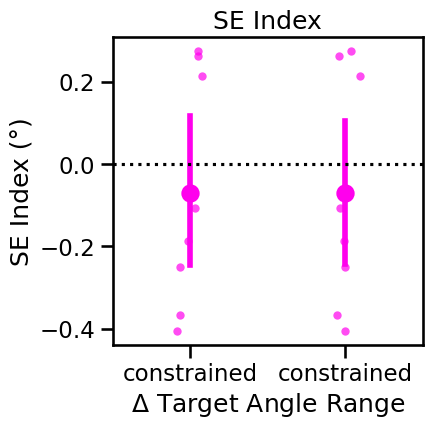

In [9]:
se_repulse_constrained = calculate_se_index(df_repulse_constrained90, "corrected_repulse_theta_pv")
se_repulse = calculate_se_index(df_repulse, "corrected_repulse_theta_pv")


se_df = pd.DataFrame({
    "REPULSE": se_repulse, 
    "REPULSE_2": se_repulse_constrained
}).reset_index()

se_df = se_df.melt(
    id_vars="SN",
    var_name="Condition",
    value_name="SE_index"
)

fig, ax = plt.subplots(figsize=(4,4))
sns.stripplot(
    data=se_df,
    x="Condition",
    y="SE_index",
    # color="black",
    alpha=0.7,
    jitter=True,
    size=6,
    ax=ax
)

sns.pointplot(
    data=se_df,
    x="Condition",
    y="SE_index",
    estimator="mean",
    errorbar=("ci",95),
    # color="black",
    linestyles="",
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")
ax.set_ylabel("SE Index (°)")
ax.set_xlabel("")
ax.set_title("SE Index")
ax.set_xticks([0, 1], labels=["constrained", "constrained"])
ax.set_xlabel(r'$\Delta$ Target Angle Range') 
# plt.savefig('SE_compare.png', dpi=600, bbox_inches='tight')
plt.show()

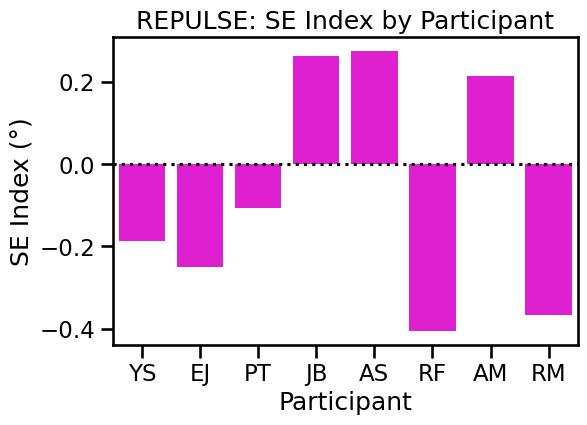

In [10]:
repulse_all = se_df[se_df["Condition"] == "REPULSE"]

subject_list = ['YS', 'EJ', 'PT', "JB", 'AS', 'RF', "AM", 'RM']

# REPULSE 
fig, ax = plt.subplots(figsize=(6,4))

sns.barplot(
    data=repulse_all,
    x=subject_list,
    y="SE_index",
    errorbar=None,
    ax=ax
)

ax.axhline(0, color="black", linestyle=":")
ax.set_xlabel("Participant")
ax.set_ylabel("SE Index (°)")
ax.set_title("REPULSE: SE Index by Participant")

# plt.savefig('SE_repulse.png', dpi=600, bbox_inches='tight')

plt.show()

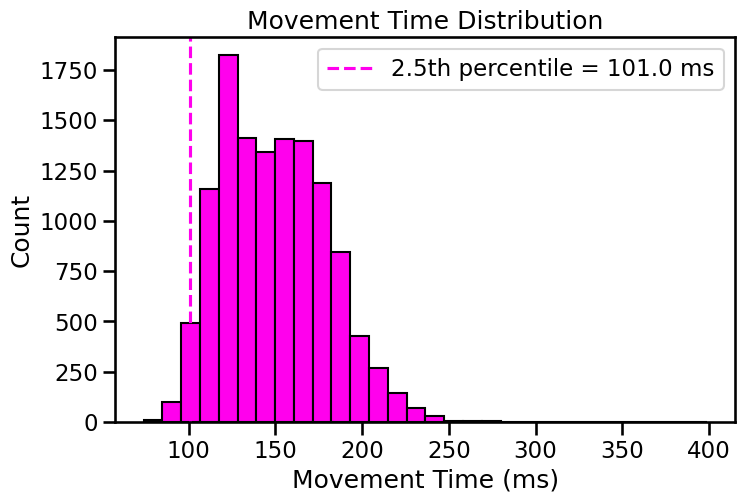

In [11]:
# Exclude baseline phase
df_no_baseline = df[df["phase"] != "baseline"]

# Movement time histogram (convert s -> ms)
mt = df_no_baseline["mt"].dropna() * 1000
bins = 30
lower_2_5 = np.percentile(mt, 2.5)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    mt,
    bins=30,
    edgecolor="black"
)

ax.axvline(
    lower_2_5,
    linestyle="--",
    label=f"2.5th percentile = {lower_2_5:.1f} ms"
)

ax.set_title("Movement Time Distribution")
ax.set_xlabel("Movement Time (ms)")
ax.set_ylabel("Count")
ax.legend()

#plt.savefig('SE_repulse.png', dpi=600, bbox_inches='tight')

plt.show()